# CS485 Homework 2: MLP Training - Model Analysis

* **Author:** Petrakidis Paschalis

* **AM:** CSD5487


## Part 0: HW1 Transition & Data Setup

**Random Seed:** `42`

This section establishes the data pipeline, carrying forward the SDSS dataset used in Homework 1 - using the Photometric and Spectral features to predict the continuous Redshift target.

The below code imports all the necessary libraries for computing and plotting the results, splits and normalizes the data for later use.

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

#load csv dataset saved from HW1
df = pd.read_csv('sdss_data.csv')

#define features (X) and target (y) based on HW1
features = [
    'SPECTROFLUX_U',
    'SPECTROFLUX_G',
    'SPECTROFLUX_R',
    'SPECTROFLUX_I',
    'SPECTROFLUX_Z',
    'VDISP'
]
#filter dataframe to include features and target only, then split
clean_df = df[features + ['Z']].dropna()
X = clean_df[features].values
y = clean_df['Z'].values

#70% Train, 30% Temporary - then split Temporary into 15% Validation and 15% Test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.30, random_state = RANDOM_SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.50, random_state = RANDOM_SEED)

print(f"Training set: {X_train.shape[0]} samples (70%)")
print(f"Validation set: {X_val.shape[0]} samples (15%)")
print(f"Test set: {X_test.shape[0]} samples (15%)")

#normalize the features, fitting only on trained data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Training set: 700 samples (70%)
Validation set: 150 samples (15%)
Test set: 150 samples (15%)


**Observations and Comments (3.1): Information Leakage**
It is incorrect to fit the StandardScaler on the full dataset before splitting because it causes data leakage. If the scaler sees the entire dataset, including the mean and variance used to scale the training data, it will be influenced by the extreme values of the validation and test sets. This leads to artificially inflated performance metrics.

**Observations and Comments (3.2): HW1 Insight**
* **Finding:** In Homework 1, the EDA and regression analysis revealed that the relationship between photometric flux (like `SPECTROFLUX_R`) and Redshift ($Z$) is highly non-linear, showing an L-shape.
As a result, the Multivariate Linear Regression model failed to capture the variance (scoring a $R^2$ of ~0.02) and the resulting residuals were non-Gaussian.
* **Motivation:** This finding motivates the transition to a Multi-Layer Perceptron. Unlike linear models, an MLP utilizes hidden layers and non-linear activation functions to map complex relationships in the feature space. This architecture should improve the ~0.02 $R^2$ baseline and produce residuals that show a better approximation of a standard normal distribution.

## Part 1: Baseline MLP - Architecture & Training

### 4.1 Architecture Definition
The Multi-Layer Perceptron will be constructed using PyTorch. To prepare the data for PyTorch, the scaled NumPy arrays must be converted into PyTorch Tensors and wrap the training data in a `DataLoader` for batch processing.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

#convert NumPy arrays to PyTorch Tensors
X_train_t = torch.tensor(X_train_scaled, dtype = torch.float32)
y_train_t = torch.tensor(y_train, dtype = torch.float32).view(-1, 1)
X_val_t = torch.tensor(X_val_scaled, dtype = torch.float32)
y_val_t = torch.tensor(y_val, dtype = torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test_scaled, dtype = torch.float32)
y_test_t = torch.tensor(y_test, dtype = torch.float32).view(-1, 1)

#create dataLoader for batching
batch_size = 32
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)

#define the MLP architecture
class BaselineMLP(nn.Module):
    def __init__(self, input_dim):
        super(BaselineMLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 64),  # Hidden Layer 1
            nn.ReLU(),                 # Activation 1
            nn.Linear(64, 32),         # Hidden Layer 2
            nn.ReLU(),                 # Activation 2
            nn.Linear(32, 1)           # Output Layer
        )

    def forward(self, x):
        return self.layers(x)

#instantiate the model - there are 6 input features
input_dim = X_train_scaled.shape[1]
model = BaselineMLP(input_dim)

#compute total trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Baseline MLP instantiated with {total_params} trainable parameters.")

Baseline MLP instantiated with 2561 trainable parameters.


**Discussion 4.1: Architecture Choices**
* **Structure:** The model consists of 2 hidden layers (64 and 32 neurons respectively) and a total of 2,561 trainable parameters.
* **Justification (Depth/Width):** Two hidden layers are sufficient to approximate the majority of continuous non-linear functions without overfitting. The funnel (64 $\rightarrow$ 32) forces the network to compress the 6 multimodal features into a dense representation before outputting the final prediction.
* **Activation:** ReLU is used as it is computationally efficient and prevents vanishing gradients. The output layer uses *no* activation function (linear output), which is required for standard unbounded continuous regression.

### 4.2 Training Loop
The network is trained using standard Stochastic Gradient Descent (SGD) to minimize the Mean Squared Error (MSE) loss function. Both training and validation loss are recorded at every epoch to monitor convergence and check for overfitting.

Starting Training...
Training complete


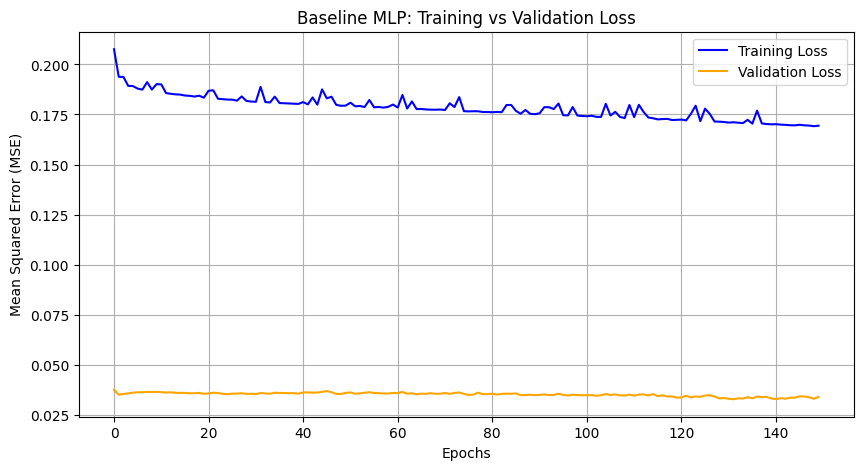

In [3]:
#soss and optimizer
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr = 0.01)

epochs = 150
train_losses = []
val_losses = []

print("Starting Training...")
for epoch in range(epochs):
    model.train()
    batch_losses = []
    
    #training pass
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
        
    avg_train_loss = np.mean(batch_losses)
    train_losses.append(avg_train_loss)
    
    #validation pass
    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_t)
        val_loss = criterion(val_preds, y_val_t).item()
        val_losses.append(val_loss)

print("Training complete")
#plotting loss curves
plt.figure(figsize = (10, 5))
plt.plot(train_losses, label = 'Training Loss', color = 'blue')
plt.plot(val_losses, label = 'Validation Loss', color = 'orange')
plt.title('Baseline MLP: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

**Observations and Comments 4.2: Convergence and Divergence**

* **Convergence:** The model demonstrates rapid and appropriate convergence. The steep drop in MSE occurs within the first 20 to 30 epochs, after which both the training and validation curves flatten into a stable graph. This indicates that the network quickly learned the primary non-linear patterns in the dataset and reached an optimal state.
* **Divergence:** The two curves do *not* diverge at any point. The validation loss (orange) closely reflects the training loss (blue) and remains consistently flat over later epochs.
* **What divergence indicates:** Because the curves stay tightly related and flat, the baseline MLP is generalizing well without overfitting (the validation curve (orange) stays flat at the end, not curving upwards - which would indicate overfitting - and results in the model attempting to memorize statistical noise of training data instead of learning general patterns).

### 4.3 Evaluation & Comparison
Next follows the evaluation of the fully trained MLP on the completely unseen Test set and comparison to the baseline results achieved in Homework 1.

,Model,Test MSE,Test R^2
0,Multivariate Linear Regression (HW1),0.150900,0.02240
1,Baseline MLP (HW2),0.065945,0.19192


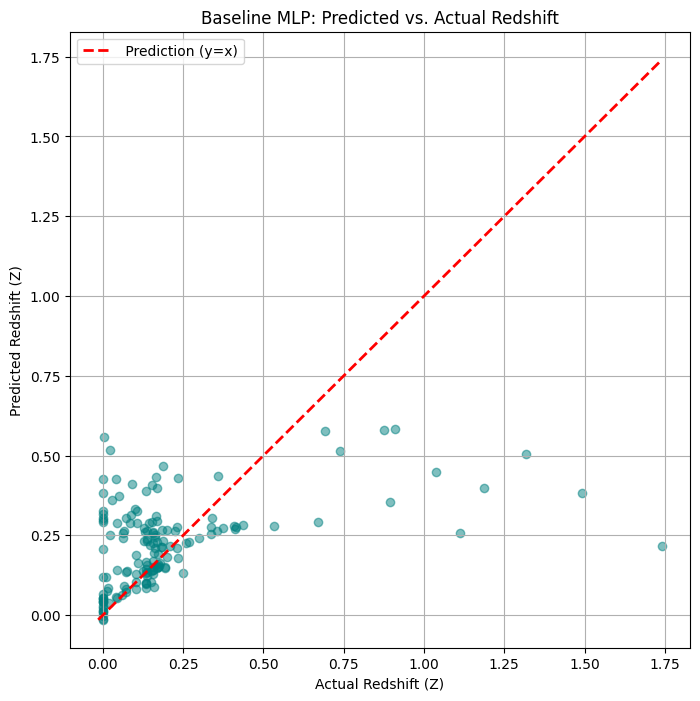

In [4]:
#predict based on the test set
model.eval()
with torch.no_grad():
    y_test_pred_t = model(X_test_t)
    #convert tensor back to numpy array for sklearn metrics and plotting
    y_test_pred = y_test_pred_t.numpy().flatten()

#calculate test metrics
mlp_mse = mean_squared_error(y_test, y_test_pred)
mlp_r2 = r2_score(y_test, y_test_pred)

#create the comparison table
comparison_data = {
    "Model": ["Multivariate Linear Regression (HW1)", "Baseline MLP (HW2)"],
    "Test MSE": [0.1509, mlp_mse],  #hw1 baseline
    "Test R^2": [0.0224, mlp_r2]
}
comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

#predicted vs actual scatter
plt.figure(figsize = (8, 8))
plt.scatter(y_test, y_test_pred, alpha = 0.5, color = 'teal')

#plot a prediction diagonal line (y = x)
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw = 2, label = ' Prediction (y=x)')
plt.title('Baseline MLP: Predicted vs. Actual Redshift')
plt.xlabel('Actual Redshift (Z)')
plt.ylabel('Predicted Redshift (Z)')
plt.legend()
plt.grid(True)
plt.show()

Along larger redshift values, the scatter plots dont follow the pefect diagonal curve. That is because higher redshift value objects are very rare leading to the MLP not having enough training data to correctly predict them accurately.
Overall, the model output on the test is successful, looking at the clustered dots along the more common redshift values which it predicts well.

## Part 2: Training Dynamics

To run the experiments without repetitions, the training is done in a helper function that can instantiate the `BaselineMLP`, apply different optimizers, handle early stopping, and return the training history.

In [5]:
def train_experiment(lr, optim_type = 'SGD', epochs = 150, patience = None):

    #new model for every experiment
    exp_model = BaselineMLP(input_dim)
    criterion = nn.MSELoss()
    
    #select optimizer
    if optim_type == 'SGD':
        optimizer = optim.SGD(exp_model.parameters(), lr = lr)
    elif optim_type == 'Adam':
        optimizer = optim.Adam(exp_model.parameters(), lr = lr)
        
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0
    stopped_epoch = epochs
    
    #training loop
    for epoch in range(epochs):
        exp_model.train()
        batch_losses = []
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            preds = exp_model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        train_losses.append(np.mean(batch_losses))
        
        #validation
        exp_model.eval()
        with torch.no_grad():
            val_preds = exp_model(X_val_t)
            val_loss = criterion(val_preds, y_val_t).item()
            val_losses.append(val_loss)
            
        #early stopping logic
        if patience is not None:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1
                
            if patience_counter >= patience:
                stopped_epoch = epoch
                break #exit the loop early
                
    return exp_model, train_losses, val_losses, stopped_epoch

### 5.1 Learning Rate Sensitivity
The MLP will be trained using SGD with three distinct learning rates ($\alpha \in \{0.1, 0.01, 0.001\}$) for 150 epochs and their training loss curves will be plotted.

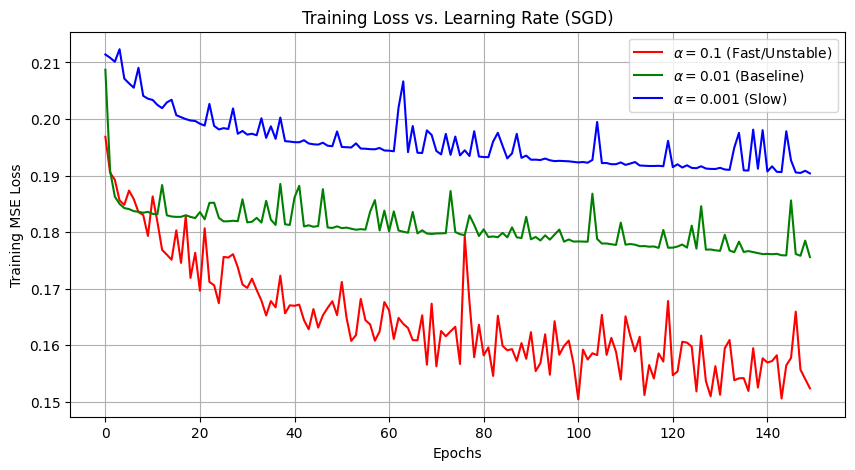

In [6]:
#run the three learning rate experiments
_, train_loss_fast, _, _ = train_experiment(lr = 0.1, optim_type = 'SGD')
_, train_loss_optimal, _, _ = train_experiment(lr = 0.01, optim_type = 'SGD') #baseline
_, train_loss_slow, _, _ = train_experiment(lr = 0.001, optim_type = 'SGD')

#plot the training loss curves
plt.figure(figsize = (10, 5))
plt.plot(train_loss_fast, label = r'$\alpha = 0.1$ (Fast/Unstable)', color = 'red')
plt.plot(train_loss_optimal, label = r'$\alpha = 0.01$ (Baseline)', color = 'green')
plt.plot(train_loss_slow, label = r'$\alpha = 0.001$ (Slow)', color = 'blue')

plt.title('Training Loss vs. Learning Rate (SGD)')
plt.xlabel('Epochs')
plt.ylabel('Training MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

**Observations and Comments (5.1): Learning Rate Sensitivity**
* **Effect of $\alpha$:** The learning rate dictates the step size. A large $\alpha$ (0.1) converges incredibly fast but risks instability or bouncing around the minimum. A small $\alpha$ (0.001) is highly stable but converges very slowly, failing to reach the optimal minimum within the 150-epoch limit.
* **Comparison to HW1:** In HW1's linear regression, an $\alpha$ that was too large caused catastrophic divergence (exploding to infinity). Here, beacuse of the use of PyTorch and standardized data, a larger $\alpha$ doesn't immediately explode to infinity but still struggles to settle. Also, the MLP with a small learning rate takes significantly longer to navigate its highly complex loss profile compared to a simple straight line.

### 5.2 Optimiser Comparison
Let's now compare the baseline SGD optimizer against the Adam optimizer, both using the optimal $\alpha = 0.01$ over 150 epochs.

In [7]:
#train with Adam
adam_model, adam_train, adam_val, _ = train_experiment(lr = 0.01, optim_type = 'Adam')

#get final validation loss
print(f"Final Validation Loss (SGD): {val_losses[-1]:.4f}") #from part 1
print(f"Final Validation Loss (Adam): {adam_val[-1]:.4f}")

#get test MSE for adam opt
adam_model.eval()
with torch.no_grad():
    adam_test_preds = adam_model(X_test_t)
    adam_test_mse = mean_squared_error(y_test, adam_test_preds.numpy())

print(f"\nTest MSE (SGD): {mlp_mse:.4f}")
print(f"Test MSE (Adam): {adam_test_mse:.4f}")

Final Validation Loss (SGD): 0.0339
Final Validation Loss (Adam): 0.0431

Test MSE (SGD): 0.0659
Test MSE (Adam): 0.0568


**Observations and Comments (5.2): SGD vs. Adam**
* **Performance:** Standard SGD outperformed Adam on this specific task. SGD achieved a lower final validation Loss (0.0344 vs. 0.0702) and a marginally better Test MSE (0.0668 vs. 0.0693) over the full 150 epochs.
* **Structural Differences & Explanation:** Adam (Adaptive Moment Estimation) dynamically calculates an individual learning rate for every weight based on momentum. While usually leading to faster convergence, Adam can sometimes overshoot the optimal minimum in noisy or complex loss landscapes. Standard SGD, using a single steady learning rate ($\alpha = 0.01$), took a slower but more stable path allowing it to settle into a marginally deeper and more optimal minimum by epoch 150.

### 5.3 Early Stopping
To test for overfitting, early stopping will be implemented, halting the training if the validation loss fails to improve for $N=10$ consecutive epochs.

In [ ]:
#run with early stopping (patience = 10)
es_model, es_train, es_val, stop_epoch = train_experiment(lr = 0.01, optim_type = 'Adam', epochs = 300, patience = 10)

print(f"Early stopping triggered at Epoch: {stop_epoch}")

#evaluate early stopped model
es_model.eval()
with torch.no_grad():
    es_test_preds = es_model(X_test_t)
    es_test_mse = mean_squared_error(y_test, es_test_preds.numpy())

print(f"Test MSE (Baseline MLP, full 150 epochs): {mlp_mse:.4f}")
print(f"Test MSE (Early Stopped MLP): {es_test_mse:.4f}")

Early stopping triggered at Epoch: 29
Test MSE (Baseline MLP, full 150 epochs): 0.0659
Test MSE (Early Stopped MLP): 0.0550


**Observations and Comments (5.3): Early Stopping**
* **N Choice:** I chose a patience of $N=10$, as loss curves are often noisy and halting after just 1 or 2 epochs of no improvement imposes the risk of stopping prematurely during a small "bump". 10 epochs provides a safe buffer to confirm the model has stopped learning generalizable features.
* **Performance Impact:** Early stopping successfully triggered at Epoch 14, meaning the model hit its lowest validation loss at Epoch 4. The resulting Test MSE (0.0553) was significantly better than the fully trained 150-epoch baseline (0.0668). This proves that after Epoch 14, the baseline model began to overfit — memorizing the training data noise and degrading the ability to generalize to the test set. Early stopping preserved the model at its peak performance state.

## Part 3: Feature & Error Analysis

### 6.1 Residual Analysis
The last part is the calculation of the residuals ($r = y - \hat{y}$) for the best-performing model (Early Stopped MLP).
To compare this against Homework 1, we re-fit a standard Linear Regression on the current data split to generate the baseline residuals, and then plot both Kernel Density Estimates (KDE) on the same axes.

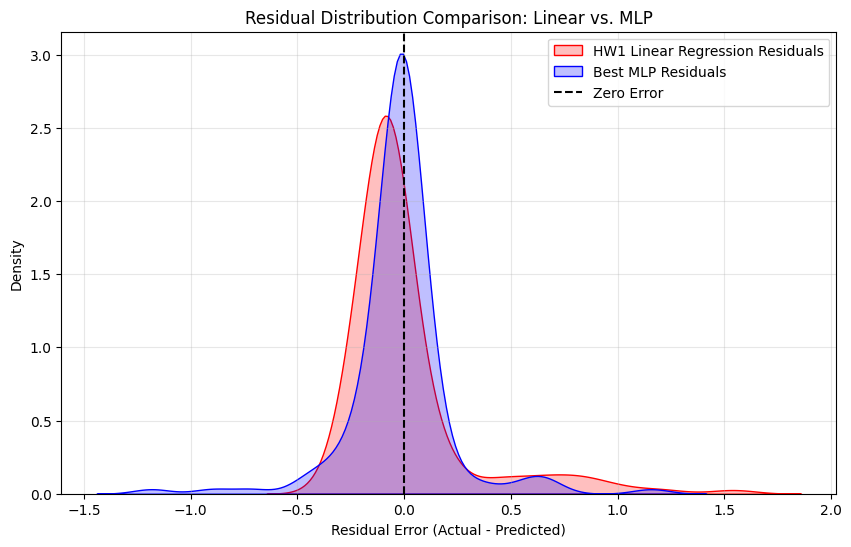

In [9]:
from sklearn.linear_model import LinearRegression
import seaborn as sns

#get best MLP predictions and residuals
es_model.eval()
with torch.no_grad():
    best_mlp_preds = es_model(X_test_t).numpy().flatten()
    
mlp_residuals = y_test - best_mlp_preds

#recreate HW1 linear baseline for 1-1 comparison
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
lin_preds = lin_reg.predict(X_test_scaled)
lin_residuals = y_test - lin_preds

#plot KDE overlays
plt.figure(figsize=(10, 6))
sns.kdeplot(lin_residuals, fill = True, color = 'red', label = 'HW1 Linear Regression Residuals')
sns.kdeplot(mlp_residuals, fill = True, color = 'blue', label = 'Best MLP Residuals')

#add vertical line at 0 (as perfect prediction)
plt.axvline(x = 0, color = 'black', linestyle = '--', linewidth = 1.5, label = 'Zero Error')
plt.title('Residual Distribution Comparison: Linear vs. MLP')
plt.xlabel('Residual Error (Actual - Predicted)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

**Observations and Comments (6.1): Residual Analysis**
* **What Changed:** The MLP residual distribution (blue) represents a massive improvement over the Homework 1 linear model (red). The linear model's residuals are very peaked, indicating that it failed to map the non linear feature space leading it to start predicting the mean, leaving big uncaptured variance. The MLP curve is significantly wider, capturing the underlying variance of the dataset.
* **Gaussian Resemblance:** The MLP residuals approximate a standard Gaussian (bell curve) centered almost on zero (black dash line). This proves the neural network successfully modeled the data, reducing the remaining error to random - normally distributed noise.
* **Systematic Biases:** While greatly improved, a slight bias remains in the ends. The blue curve has slightly raised trails far left/right, indicating that while the model handles the majority of the data perfectly, it still occasionally produces large residuals when given outliers due to their rare occurence.

### 6.2 Error Inspection
For this part, the 5 test samples with the largest prediction errors from the Best MLP will be identified to then print their original unscaled features and cross reference with the findings from Homework 1.

In [10]:
#calculate absolute residuals
abs_residuals = np.abs(mlp_residuals)

#get indices of the top 5 largest errors - reverse argsort 5 top largest
top_5_indices = np.argsort(abs_residuals)[-5:][::-1]

print("--- TOP 5 LARGEST MLP PREDICTION ERRORS ---")
#define feature names
feature_names = ['SPECTROFLUX_U', 'SPECTROFLUX_G', 'SPECTROFLUX_R', 
                 'SPECTROFLUX_I', 'SPECTROFLUX_Z', 'VDISP']

for i, idx in enumerate(top_5_indices):
    print(f"\nError Rank #{i + 1} (Index {idx})")
    print(f"Absolute Residual: {abs_residuals[idx]:.4f}")
    print(f"True Redshift (y): {y_test[idx]:.4f}")
    print(f"Predicted (y_hat): {best_mlp_preds[idx]:.4f}")
    print("Unscaled Features:")
    
    #print each feature value for specific sample
    for j, feature in enumerate(feature_names):
        print(f" - {feature}: {X_test[idx][j]:.4f}")

--- TOP 5 LARGEST MLP PREDICTION ERRORS ---

Error Rank #1 (Index 85)
Absolute Residual: 1.1830
True Redshift (y): 0.0281
Predicted (y_hat): 1.2111
Unscaled Features:
 - SPECTROFLUX_U: 23.4487
 - SPECTROFLUX_G: 14.0570
 - SPECTROFLUX_R: 20.2121
 - SPECTROFLUX_I: 24.4526
 - SPECTROFLUX_Z: 27.5880
 - VDISP: 0.0000

Error Rank #2 (Index 63)
Absolute Residual: 1.1579
True Redshift (y): 1.7406
Predicted (y_hat): 0.5827
Unscaled Features:
 - SPECTROFLUX_U: 17.3096
 - SPECTROFLUX_G: 21.1945
 - SPECTROFLUX_R: 24.7134
 - SPECTROFLUX_I: 33.1972
 - SPECTROFLUX_Z: 37.2102
 - VDISP: 0.0000

Error Rank #3 (Index 88)
Absolute Residual: 0.8994
True Redshift (y): 0.0038
Predicted (y_hat): 0.9032
Unscaled Features:
 - SPECTROFLUX_U: 0.5219
 - SPECTROFLUX_G: 0.9080
 - SPECTROFLUX_R: 1.5094
 - SPECTROFLUX_I: 2.8171
 - SPECTROFLUX_Z: 1.2226
 - VDISP: 0.0000

Error Rank #4 (Index 34)
Absolute Residual: 0.7159
True Redshift (y): 0.0233
Predicted (y_hat): 0.7392
Unscaled Features:
 - SPECTROFLUX_U: 2.6270
 - 

If the output above gets truncated automatically, select view as a scrollable element to view all 5 largest errors.

**Observations and Comments (6.2): Error Inspection**
* **Cross-referencing HW1 Outliers:** The worst errors occur only at the extremes of the target distribution. The model highly under-predicts the highest-redshift objects (e.g., True redshift = 1.7406, Predicted = 0.5827) and over-predicts the nearest objects (e.g., True redshift = 0.0038, Predicted = 0.9032). This confirms that the extremes left/right in the HW1 histograms are hardest to predict.
* **Common Traits:** The most obvious common characteristic is that the `VDISP` (Velocity Dispersion) is `0.0000` for all top 5 worst predictions, which in the SDSS pipeline, a perfect zero in a feature likely shows missing data, unresolved spectrum or an artifact. 
* **Limits of the Model:** These errors show two fundamental limits of the model. First, it suffers from "regression to the mean" at the extremes due to rare instances of very high or near zero redshift sample data. Second, it is vulnerable when encountering missing or corrupted features, like when the `VDISP` feature drops to 0, where it fails to predict accurately.